Based on the paper column of scraped/ijhs.tsv, classify each paper into the best among the following Subject , Category Subject: 1) Astronomy 2) Math 3) Medicine 4)Agriculture 5)Culture 6)Metallurgy 7)Mind sciences Category: a) Dharmic b) Islamic c)Western d)Fareast

Use pandas to load the csv.  Assume I have ollama/llama3.2 locally installed and running. Use the llama3.2 to classify the paper into the best subject and category.  The output should be a csv file with the following columns added subject  and category.  The output file should be named ijhs_classified.tsv

In [1]:
from time import sleep, time

from tqdm.notebook import tqdm
import pickle
import os
import re
import json
import pandas as pd
from pydantic import BaseModel

from ollama import chat, generate
import google.generativeai as genai
from google.generativeai.types import RequestOptions 
from google.api_core import retry

from dotenv import load_dotenv ; load_dotenv() ;

In [3]:
genai.configure(api_key=GOOGLE_API_KEY)
for model in genai.list_models():
    if "createTunedModel" in model.supported_generation_methods:
        print(model.name)

NameError: name 'GOOGLE_API_KEY' is not defined

In [2]:
class Cache2Disk(): # using pickle
  """A class for caching objects to disk using pickle serialization.

  This class provides a simple interface to cache Python objects to disk using pickle,
  with automatic file path handling based on provided arguments.

  Args:
    *args: Variable length argument list used to construct the cache filename.
        Arguments are joined with underscores and prefixed with '_cache'.

  Attributes:
    filename (str): The full path to the cache file, constructed from args.
    item: The cached object (only exists after save/load operations).

  Methods:
    save(item): Saves an item to the cache file.
    load(): Loads and returns the cached item from disk.

  Raises:
    Exception: When load() is called and cache file doesn't exist or is empty.

  Example:
    >>> cache = Cache2Disk('mydata', 'v1')
    >>> cache.save({'key': 'value'})
    >>> data = cache.load()
  """
  def __init__(self, *args):
    # join all args to create a filename in $CACHEDIR or /tmp
    filename = os.path.join(os.getenv('CACHEDIR', '/tmp'), '_'.join(['_cache'] + list(args)))
    # print(f"Cache file: {filename}")
    self.filename = filename

  def save(self, item):
    self.item = item  
    with open(self.filename, 'wb') as f:
      pickle.dump(self.item, f)
    return self.item

  def load(self):
    try :
      with open(self.filename, 'rb') as f:
        self.item = pickle.load(f)
    except:
      self.item = None

    if self.item is None : raise Exception("Cache miss")
    return self.item


In [9]:
import enum
import typing_extensions as typing

class PaperSubject(enum.Enum):
    Astronomy = "Astronomy"
    Math = "Math"
    Medicine = "Medicine"
    Agriculture = "Agriculture"
    Culture = "Culture"
    Metallurgy = "Metallurgy"
    MindSciences = "MindSciences"
    Biology = "Biology"
    Philosophy = "Philosophy"
    Lingiustics = "Lingiustics"
    Music = "Music"
    Other = "Other"

class PaperCategory(enum.Enum):
    Indic = "Indic"
    Arabic = "Arabic"
    Western = "Western"
    Fareast = "Fareast"
    Other = "Other"

class PaperClassification(typing.TypedDict, total=True):
    subject: PaperSubject
    category: PaperCategory 
    journal: str
    paper: str

class PaperClassifications(typing.TypedDict):
    classifications: list[PaperClassification]

class BaseGeminiClassifier():

  """
  Base class for Gemini-based paper classification.
  This class provides core functionality for classifying academic papers using Google's Gemini AI model.
  It handles model configuration, initialization, and basic classification operations.

  Attributes:
    model: The initialized Gemini generative model instance
    tags: String concatenation of model tags for identification
    peek: Boolean flag to enable preview of classification results
    force: Boolean flag to force cache miss and regenerate classifications

  Methods:
    model_config_params(): Returns model configuration parameters
    model_name(): Returns the name of the Gemini model to use
    model_tags(): Returns tags identifying the model instance
    model_system_prompt(): Returns the system prompt for classification
    prep_response_text(response_text): Preprocesses model response text
    __init__(**kwargs): Initializes the classifier with optional peek and force flags

  Configuration:
    The class expects GEMINI_API_KEY to be set in environment variables
    Default model: gemini-2.0-flash-exp
    Default temperature: 0.0 (deterministic)
    Default response format: JSON
  Example:
    >>> classifier = BaseGeminiClassifier(peek=True)
  """

  def model_config_params(self):
    return {
      "temperature": 0.0,
      "top_p": 0.95,
      "top_k": 5,
      "max_output_tokens": 8192,
      "response_mime_type": "application/json",
      "response_schema": PaperClassifications
    }
  
  def model_name(self):
    return "gemini-2.0-flash-exp"
  
  def model_tags(self):
    return ['gemini', self.__class__.__name__]
  
  def model_system_prompt(self):
    return f"""
    You are an expert in history of science. 
    Classify each paper into its best Subject and best Category. Do not return empty classifications.
    """
  
  def prep_response_text(self, response_text):
    return response_text
  
  def plot_classified_df(self):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import warnings
    warnings.filterwarnings("ignore")
    
    plt.figure(figsize=(16, 6))
    sns.set_theme(style="whitegrid")
    sns.countplot(data=self.classified_df, hue='category', x='subject')
    plt.title(f"Count of papers by category vs subject: {self.__class__.__name__}")
    plt.show()
  
  def __init__(self, **kwargs):
    # Configure Gemini API
    genai.configure(api_key=os.getenv('GEMINI_API_KEY'))

    self.model = genai.GenerativeModel(
      model_name=self.model_name(),
      generation_config=genai.GenerationConfig(**(self.model_config_params())),
    )
    self.tags = "_".join(self.model_tags())
    self.peek = kwargs.get('peek', False)
    self.force = kwargs.get('force', False)

  def classify_one_batch(self, in_df ):
    prompt = f"""{self.model_system_prompt()}
Papers: {in_df[['journal', 'paper']].to_dict(orient='records')}
"""
    # When running lots of queries, it's a good practice to use a retry policy so your code
    # automatically retries when hitting Resource Exhausted (quota limit) errors.
    retry_policy = RequestOptions(
        retry = retry.Retry(predicate=retry.if_transient_error, initial=10, multiplier=1.5, timeout=300)
    )
    
    response = self.model.generate_content(prompt , request_options=retry_policy)
    return response

  def classify_in_batches(self, df, batch_size=15*1):
    results = []
    total_batches = (len(df) + batch_size - 1) // batch_size
    forced = "[forced]" if self.force else ""
    pbar =  tqdm(enumerate(range(0, len(df), batch_size)), 
             desc=f"{self.__class__.__name__} papers {forced}",
             total=total_batches,
             unit='batch')
    time_start = time()
    time_prev = time_start 
    for ix, i in pbar:
      # cache = Cache2Disk('gemini', 'classify', 'typed' , f"{i}-{i+batch_size}")
      cache = Cache2Disk( *self.model_tags() , f"{i}-{i+batch_size}")
      # print(f"Cache file: {cache.filename}")
      time_now = time()
      time_since_start = f"{(time_now - time_start) // 60:3.0f}m{(time_now - time_start) % 60:2.0f}s"
      time_since_prev = f"{(time_now - time_prev) // 60:3.0f}m{(time_now - time_prev) % 60:2.0f}s"
      try :
        if self.force: raise Exception("Forcing cache miss")
        response= cache.load()
        response_text = self.prep_response_text(response.text)
        # json.loads(response.text[8:-4])['classifications'][0]['journal']
        check_df = pd.DataFrame(json.loads(response_text)['classifications'])
        if check_df.category.isna().sum() > 0 : raise Exception("Some categories are missing")
        if check_df.subject.isna().sum() > 0 : raise Exception("Some subjects are missing")
        if ix < (total_batches-1): # last batch need not be full
          if len(check_df) != batch_size: raise Exception(f"Batch {ix} size mismatch . Expected {batch_size} got {len(check_df)}")  
        check_df[['journal' , 'category' , 'subject', 'paper']] # just to make sure it's a valid response
        if ((self.peek) & (ix>60) & ((ix%20)==0)): display(f"{i=} {ix=}", check_df.sample(5))
        # pbar.write(f"Cache hit: {cache.filename} {i=} {ix=} {check_df.isna().sum().sum()} {check_df.shape}")
      except Exception as e:
        pbar.write(f"{time_since_start} {time_since_prev} *** {e}: {cache.filename} {i=} {ix=}; regenerating")
        for tries in range(2):       
          pbar.write(f"***===> Retry {tries+1} due to ({e}) : {cache.filename}; regenerating")
          response = self.classify_one_batch(df.iloc[i:i+batch_size].sample(frac=1))
          response_text = self.prep_response_text(response.text)
          sleep(1)
          self.last_response = response # for debugging
          try :
            check_df = pd.DataFrame(json.loads(response_text)['classifications'])
            pbar.write(f"***===> Retry {tries+1} successful")
          except Exception as e:
            pbar.write(f"*** Error {e}; retrying with raw response.text")
            check_df = pd.DataFrame(json.loads(response.text)['classifications'])
          # display(check_df.sample(2), check_df.shape)
          display(check_df.shape)
          mandatory_cols = ['journal' , 'category' , 'subject', 'paper']
          if all([c in check_df.columns for c in mandatory_cols]): # just to make sure it's a valid response
            cache.save(response)
            break
          else:
            pbar.write(f"*** Error: Missing columns {mandatory_cols} in response; retrying")
            continue

      # results.append(pd.DataFrame(json.loads(response.text[8:-4])['classifications']))
      # results.append(pd.DataFrame(json.loads(response_text)['classifications']))
      results.append(check_df)
      num_papers = pd.Series([ d.shape[0] for d in results]).sum()
      # ttl_papers = len(IJHS)
      ttl_papers = len(df)
      status_str = f"{num_papers}/{ttl_papers} - {100*num_papers/ttl_papers:.0f}% - {ix+1}"
      pbar.set_postfix({
        "papers": status_str,
        # "last paper": df.iloc[i+batch_size-1]['paper'][:10] , 
      })
      # print(status_str)
      time_prev = time_now
      # if ix > 10: break
    ans = pd.concat(results).reset_index(drop="index") if results else pd.DataFrame()
    pbar.write(f"====== Total papers classified: {ans.shape} na_cnt={ans.isna().sum().sum()}")
    return ans
    # return results[0]

  def classify_df(self, df):
    ans = self.classify_in_batches(df)
    return ans
  
  def classify_ijhs(self):
    ijhs = pd.read_csv('scraped/ijhs.tsv', sep="\t")
    ijhs.paper = ijhs.paper.str.strip()
    # ijhs.journal = ijhs.paper.str.strip()
    ans = self.classify_df(ijhs)
    ans.paper = ans.paper.str.strip()
    # ans.journal = ans.paper.str.strip()
    ijhs = ijhs.merge(ans, on=['journal', 'paper'], how='left')

    cfn = f'scraped/ijhs-classified-{self.tags}.tsv'
    ijhs.to_csv(cfn, sep="\t", index=False)
    self.classified_df = ijhs
    return ijhs
  
  def md_the_classification(self):
    # Read the TSV file
    df = self.classified_df.copy().dropna()
    df['#'] = df.index + 1
  
    df.sort_values(by=['#'], inplace=True)
    
    # Round size_in_kb to nearest integer
    df['size_in_kb'] = df['size_in_kb'].round().astype(int)
    
    # Create markdown table
    md = "# Indian Journal of History of Science - Classified Papers\n\n"
    md += "| # | Journal | Subject | Category | Paper | Author | Size (KB) |\n"
    md += "|---|---------|---------|----------|-------|--------|------------|\n"
    
    for _, row in df.iterrows():
        md += f"| {row['#']} | {row['journal']} | {row['subject']} | {row['category']} | [{row['paper']}]({row['url']}) | {row['author']} | {row['size_in_kb']} |\n"
    
    # Generate output filename
    out_file = f'scraped/ijhs-classified-{self.tags}.md'
    
    # Write markdown file
    with open(out_file, 'w', encoding='utf-8') as f:
        f.write(md)

    print(f"Markdown file written to {out_file}")
        
    return out_file
  
  def sanity_check(self, df) :
    ans = self.classify_one_batch(df)
    ans_text = self.prep_response_text(ans.text)  
    try:
      ans_df = pd.DataFrame(json.loads(ans_text)['classifications'])
      df = df.merge(ans_df, on=['journal', 'paper'], how='left')
      return df
    except Exception as e:
      print(f"*** Error {e}")
      return ans
    
class JsonGeminiClassifier(BaseGeminiClassifier):
  """A Gemini-based classifier that processes and returns JSON output.

  This classifier extends BaseGeminiClassifier to specifically handle JSON-formatted
  classification results. It implements tag-based classification using the Gemini
  model with typed outputs.

  Attributes:
    Inherits all attributes from BaseGeminiClassifier

  Methods:
    model_tags(): Returns the classifier's model tags

  Returns:
    list: The tags associated with this classifier ['gemini', 'classify', 'typed']
  """
  def model_tags(self):
    return ['gemini', 'classify', 'typed']
  
class TextGeminiClassifier(BaseGeminiClassifier):
  """
  A classifier that uses Google's Gemini model to classify scientific papers by subject and category.
  This classifier extends BaseGeminiClassifier to provide specialized classification of scientific paper
  topics into predefined subjects (e.g. Astronomy, Math, Medicine) and categories (e.g. Indic, Arabic, Western).
  Attributes:
    None
  Methods:
    model_config_params() -> dict:
      Returns configuration parameters for the Gemini model.
    model_name() -> str:
      Returns the name of the Gemini model being used.
    model_tags() -> list:
      Returns tags describing the model's purpose.
    prep_response_text(response_text: str) -> str:
      Preprocesses the model's response text by extracting and validating JSON.
    model_system_prompt() -> str:
      Returns the system prompt that instructs Gemini how to classify papers.
  Example:
    >>> classifier = TextGeminiClassifier()
    >>> classifications = classifier.classify(paper_topics)
  """

  def model_config_params(self):
    return {
      "temperature": 0.0,
      "top_p": 0.95,
      "top_k": 5,
      "max_output_tokens": 8192,
      "response_mime_type": "text/plain",
      # "response_schema": PaperClassifications
    }

  def model_name(self):
    return "gemini-2.0-flash-exp"
  
  def model_tags(self):
    return ['gemini', 'classify', 'text']
  
  def prep_response_text(self, response_text):
    try:
      rpart = response_text[8:-4]
      json.loads(rpart)
      return rpart
    except Exception as e:
      return response_text

  
  def model_system_prompt(self):  
    # Given a newline-separated list of scientific paper topics, 
    # Classify each topic into its respective Subject and Category.
    return """
    You are an expert in history of science. 
    Classify each paper into its best Subject and best Category. Do not return empty classifications.

    Subject (choose exactly one string):
      Astronomy
      Math
      Medicine
      Agriculture
      Culture
      Metallurgy
      MindSciences
      Biology
      Philosophy
      Lingiustics
      Music
      Other

    Category (choose exactly one string):
      Indic
      Arabic
      Western
      Fareast
      Other

    Please provide your classifications in strictly valid JSON format.
    Do not wrap the JSON in Markdown fences or additional text. 
    Example of the expected JSON structure:
      {{
        "classifications": [
          {{
            "subject": "...",
            "category": "..."
            "journal":"..."
            "paper": "..."
          }},
          ...
        ]
      }}    
    """

textBased = TextGeminiClassifier(peek=not True)
textBased.classify_ijhs() 

jsonBased = JsonGeminiClassifier(peek=not True)
jsonBased.classify_ijhs(); 


TextGeminiClassifier papers :   0%|          | 0/130 [00:00<?, ?batch/s]

====== Total papers classified: (1940, 4) na_cnt=0


JsonGeminiClassifier papers :   0%|          | 0/130 [00:00<?, ?batch/s]

====== Total papers classified: (1940, 4) na_cnt=0


In [17]:
display(
{ 
  textBased.__class__.__name__ : { 
    "shape" : textBased.classified_df.shape
  },
  jsonBased.__class__.__name__ : { 
    "shape" : jsonBased.classified_df.shape
  }
} , pd.DataFrame(textBased.classified_df.iloc[:].isna().sum(), columns=['error']).merge(
  pd.DataFrame(jsonBased.classified_df.iloc[:].isna().sum(), columns=['error']), 
  left_index=True, right_index=True, suffixes=('_text', '_json')
),
textBased.classified_df[textBased.classified_df.category.isna()].style.set_caption('<b>NAs in jsonBased</b>') if textBased.classified_df.category.isna().sum()>0 else 'No NAs in textBased',
jsonBased.classified_df[jsonBased.classified_df.category.isna()].style.set_caption('<b>NAs in jsonBased</b>') if jsonBased.classified_df.category.isna().sum()>0 else 'No NAs in jsonBased',
textBased.classified_df[jsonBased.classified_df.category.isna()].style.set_caption('<b>jsonNAs in text</b>') if jsonBased.classified_df.category.isna().sum()>0 else 'No NAs in jsonBased',
jsonBased.classified_df[textBased.classified_df.category.isna()].style.set_caption('<b>textNAs in json</b>') if textBased.classified_df.category.isna().sum()>0 else 'No NAs in textBased'
)


{'TextGeminiClassifier': {'shape': (1940, 8)},
 'JsonGeminiClassifier': {'shape': (1940, 8)}}

,error_text,error_json
journal,0,0
paper,0,0
author,0,0
url,0,0
size_in_kb,8,8
cum_size_in_kb,8,8
subject,0,1
category,0,1


'No NAs in textBased'

,journal,paper,author,url,size_in_kb,cum_size_in_kb,category,subject
1712,IJHS-54-2019-Issue-1,Editing Karaābharaa: A commentary on Karanaprakāśa by Śankaranārāyana Joyisa,K Mahesh,https://insa.nic.in//writereaddata/UpLoadedFiles/IJHS/Vol54_1_2019__Art13.pdf,142.000000,1023893.000000,nan,nan


,journal,paper,author,url,size_in_kb,cum_size_in_kb,subject,category
1712,IJHS-54-2019-Issue-1,Editing Karaābharaa: A commentary on Karanaprakāśa by Śankaranārāyana Joyisa,K Mahesh,https://insa.nic.in//writereaddata/UpLoadedFiles/IJHS/Vol54_1_2019__Art13.pdf,142.000000,1023893.000000,Astronomy,Indic


'No NAs in textBased'

,Total Categories,Total Subjects,Common Categories,Common Subjects,Category Overlap %,Subject Overlap %
jsonBased,5.0,14.0,5.0,12.0,83.33,80.0
textBased,6.0,13.0,5.0,12.0,83.33,80.0


subject,Agriculture,Astronomy,Biology,Chemistry,Culture,Lingiustics,Math,Medicine,Metallurgy,MindSciences,Music,Other,Philosophy,Physics,All
subject,,,,,,,,,,,,,,,
Agriculture,88.5%,0.0%,6.6%,0.0%,1.6%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,3.3%,0.0%,0.0%,100.0%
Astronomy,0.0%,92.3%,0.0%,0.0%,0.0%,0.0%,3.7%,0.3%,0.0%,0.0%,0.0%,3.1%,0.6%,0.0%,100.0%
Biology,0.0%,0.0%,90.0%,0.0%,2.2%,0.0%,0.0%,4.4%,0.0%,0.0%,0.0%,3.3%,0.0%,0.0%,100.0%
Culture,1.6%,1.6%,1.6%,0.0%,70.2%,0.0%,0.0%,0.8%,4.8%,0.0%,0.8%,18.5%,0.0%,0.0%,100.0%
Lingiustics,0.0%,0.0%,0.0%,0.0%,4.0%,84.0%,0.0%,0.0%,4.0%,0.0%,0.0%,8.0%,0.0%,0.0%,100.0%
Math,0.0%,1.4%,0.0%,0.0%,0.0%,0.0%,96.7%,0.0%,0.0%,0.0%,0.0%,0.9%,0.9%,0.0%,100.0%
Medicine,0.0%,0.0%,0.8%,0.0%,0.4%,0.0%,0.0%,91.7%,6.0%,0.8%,0.0%,0.4%,0.0%,0.0%,100.0%
Metallurgy,0.0%,0.0%,0.0%,0.0%,0.6%,0.6%,0.0%,0.0%,96.8%,0.0%,0.0%,1.9%,0.0%,0.0%,100.0%
MindSciences,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,5.9%,0.0%,88.2%,0.0%,0.0%,5.9%,0.0%,100.0%


subject,Agriculture,Astronomy,Biology,Chemistry,Culture,Lingiustics,Math,Medicine,Metallurgy,MindSciences,Music,Other,Philosophy,Physics,All
subject,,,,,,,,,,,,,,,
Agriculture,90.0%,0.0%,4.3%,0.0%,0.9%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.3%,0.0%,0.0%,3.1%
Astronomy,0.0%,95.3%,0.0%,0.0%,0.0%,0.0%,5.5%,0.4%,0.0%,0.0%,0.0%,1.7%,3.6%,0.0%,16.8%
Biology,0.0%,0.0%,87.1%,0.0%,1.7%,0.0%,0.0%,1.7%,0.0%,0.0%,0.0%,0.5%,0.0%,0.0%,4.6%
Culture,3.3%,0.6%,2.2%,0.0%,75.0%,0.0%,0.0%,0.4%,3.2%,0.0%,14.3%,3.9%,0.0%,0.0%,6.4%
Lingiustics,0.0%,0.0%,0.0%,0.0%,0.9%,91.3%,0.0%,0.0%,0.5%,0.0%,0.0%,0.3%,0.0%,0.0%,1.3%
Math,0.0%,0.9%,0.0%,0.0%,0.0%,0.0%,92.7%,0.0%,0.0%,0.0%,0.0%,0.3%,3.6%,0.0%,10.9%
Medicine,0.0%,0.0%,2.2%,0.0%,0.9%,0.0%,0.0%,95.9%,8.1%,9.5%,0.0%,0.2%,0.0%,0.0%,13.0%
Metallurgy,0.0%,0.0%,0.0%,0.0%,0.9%,4.3%,0.0%,0.0%,81.6%,0.0%,0.0%,0.5%,0.0%,0.0%,8.0%
MindSciences,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.4%,0.0%,71.4%,0.0%,0.0%,1.8%,0.0%,0.9%


subject,Agriculture,Astronomy,Biology,Chemistry,Culture,Lingiustics,Math,Medicine,Metallurgy,MindSciences,Music,Other,Philosophy,Physics,All
subject,,,,,,,,,,,,,,,
Agriculture,54,0,4,0,1,0,0,0,0,0,0,2,0,0,61
Astronomy,0,301,0,0,0,0,12,1,0,0,0,10,2,0,326
Biology,0,0,81,0,2,0,0,4,0,0,0,3,0,0,90
Culture,2,2,2,0,87,0,0,1,6,0,1,23,0,0,124
Lingiustics,0,0,0,0,1,21,0,0,1,0,0,2,0,0,25
Math,0,3,0,0,0,0,204,0,0,0,0,2,2,0,211
Medicine,0,0,2,0,1,0,0,231,15,2,0,1,0,0,252
Metallurgy,0,0,0,0,1,1,0,0,151,0,0,3,0,0,156
MindSciences,0,0,0,0,0,0,0,1,0,15,0,0,1,0,17


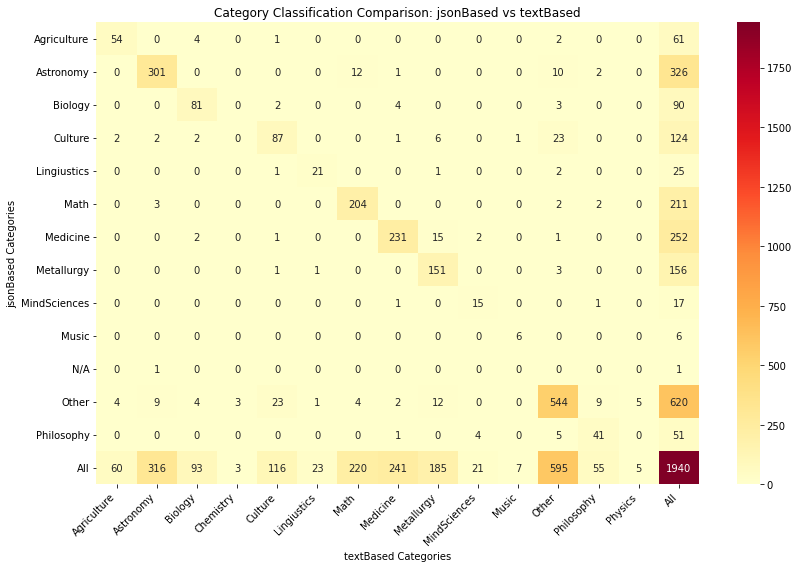

category,Arabic,Fareast,Indic,Other,Western,All
category,,,,,,
Arabic,95.7%,0.0%,2.2%,2.2%,0.0%,100.0%
Fareast,0.0%,95.2%,4.8%,0.0%,0.0%,100.0%
Indic,0.8%,0.2%,96.0%,1.9%,1.1%,100.0%
N/A,0.0%,0.0%,100.0%,0.0%,0.0%,100.0%
Other,0.2%,0.9%,20.4%,72.6%,5.9%,100.0%
Western,0.0%,0.0%,15.2%,2.9%,81.9%,100.0%
All,2.9%,1.3%,70.6%,18.6%,6.6%,100.0%


category,Arabic,Fareast,Indic,Other,Western,All
category,,,,,,
Arabic,78.6%,0.0%,0.1%,0.3%,0.0%,2.4%
Fareast,0.0%,76.9%,0.1%,0.0%,0.0%,1.1%
Indic,19.6%,7.7%,91.8%,6.9%,11.7%,67.5%
N/A,0.0%,0.0%,0.1%,0.0%,0.0%,0.1%
Other,1.8%,15.4%,6.8%,92.0%,21.1%,23.6%
Western,0.0%,0.0%,1.2%,0.8%,67.2%,5.4%
All,100.0%,100.0%,100.0%,100.0%,100.0%,100.0%


category,Arabic,Fareast,Indic,Other,Western,All
category,,,,,,
Arabic,44,0,1,1,0,46
Fareast,0,20,1,0,0,21
Indic,11,2,1257,25,15,1310
N/A,0,0,1,0,0,1
Other,1,4,93,332,27,457
Western,0,0,16,3,86,105
All,56,26,1369,361,128,1940


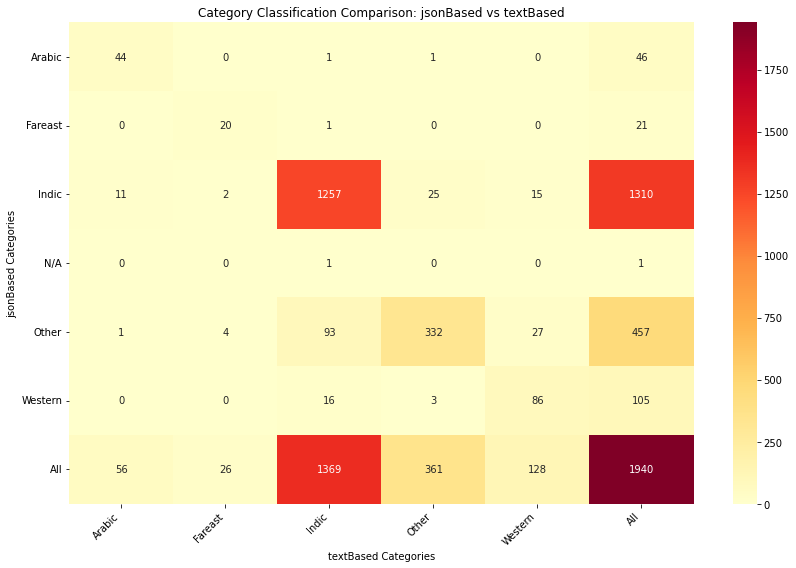

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def compare_category_classifications(json_df, text_df, slice='category'):
    jslice = json_df[slice].fillna('N/A')
    tslice = text_df[slice].fillna('N/A')

    # Create confusion matrix
    conf_matrix = pd.crosstab(
        jslice,
        tslice,
        margins=True
    )

    # Create accuracy matrix assuming jsonBased as ground truth
    accuracy_matrix = conf_matrix.divide(conf_matrix['All'], axis=0)
    display(
        accuracy_matrix.style.set_caption(
            f'<b>{slice} classification accuracy matrix - json on Y vs text on X</b> - Json as ground Truth'
        ).background_gradient(cmap='YlOrRd'
        ).format("{:.1%}")
    )

    # Create accuracy matrix assuming textBased as ground truth
    accuracy_matrix = conf_matrix.divide(conf_matrix.loc['All'], axis=1)
    display(accuracy_matrix.style.set_caption(
        f'<b>{slice} classification accuracy matrix - text on Y vs json on X</b> - Text as ground Truth'
        ).background_gradient(cmap='YlOrRd'
        ).format("{:.1%}")
    )
    
    # Plot heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(conf_matrix, 
                annot=True, 
                fmt='d',
                cmap='YlOrRd')
    
    plt.title('Category Classification Comparison: jsonBased vs textBased')
    plt.xlabel('textBased Categories')
    plt.ylabel('jsonBased Categories')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    return conf_matrix

# Usage:
for slice in ['subject', 'category']:
    matrix = compare_category_classifications(jsonBased.classified_df, textBased.classified_df, slice=slice)
    # highlight the maximum value in each row excluding the last column

    display(matrix.style.apply(lambda x: ['background: lightgreen' if v == x[:-1].max() else '' for v in x], axis=1).set_caption(f'<b>{slice} classification comparison - json on Y vs text on X</b>'))
    # display(matrix)
    plt.show()

In [33]:
jsonBased.md_the_classification()
textBased.md_the_classification()

Markdown file written to scraped/ijhs-classified-gemini_classify_typed.md
Markdown file written to scraped/ijhs-classified-gemini_classify_text.md


'scraped/ijhs-classified-gemini_classify_text.md'

In [43]:
for x in [textBased, jsonBased] : 
    jdf = x.classified_df
    display(jdf[ 
        jdf.author.str.lower().apply(lambda x: 'iyengar' in x)
        | jdf.paper.str.lower().apply(lambda x: 'iyengar' in x)
    ].style.set_caption(f"<b>{x.__class__.__name__} - Iyengar</b>").format({
        'url': lambda x: f'<a href="{x}">link</a>',
        'size_in_kb': "{:.0f}",
        'cum_size_in_kb': "{:.0f}",
    }))


,journal,paper,author,url,size_in_kb,cum_size_in_kb,subject,category
743,IJHS-34-1999-Issue-3,Earthquake History of India in Medieval Times,R N Iyengar et al.,link,909,181221,Other,Indic
834,IJHS-38-2003-Issue-2,Internal Consistency of Eclipses and Planetary Positions in Mahabharata,R N Iyengar,link,2037,210296,Astronomy,Indic
862,IJHS-39-2004-Issue-1,Profile of A Natural Disaster in Ancient Sanskrit Literature,R N Iyengar,link,621,230280,Other,Indic
904,IJHS-40-2005-Issue-2,Eclipse Period Number 3339 in the Ṛgveda,RN Iyengar,link,5391,275838,Astronomy,Indic
939,IJHS-41-2006-Issue-1,Some Celestial Observations associated with Krsna–lore,R N Iyengar,link,204,619660,Astronomy,Indic
1020,IJHS-43-2008-Issue-1,Archaic Astronomy of Parauara and Vrddha Garga,R N Iyengar,link,220,654053,Astronomy,Indic
1089,IJHS-44-2009-Issue-3,Connections Between The Vedanga Jyotisa And Other Vedic Literature,R N Iyengar,link,46,668691,Astronomy,Indic
1114,IJHS-45-2010-Issue-1,Comets and Meteoritic Showers in the Rigveda and their significance,R.N. Iyengar,link,113,671375,Astronomy,Indic
1225,IJHS-46-2011-Issue-3,Historical Notes: Archaeo-Astronomical Significance of the Vedic Darsapaurnamasa Altar,R N Iyengar and V H Satheeshkumar,link,536,691326,Astronomy,Indic
1282,IJHS-47-2012-Issue-3,Historical Notes: Archaeo-Astronomical Significance of the Vedic Darsapaurnamasa Altar,R N Iyengar and V H Satheeshkumar,link,536,711151,Astronomy,Indic


,journal,paper,author,url,size_in_kb,cum_size_in_kb,category,subject
743,IJHS-34-1999-Issue-3,Earthquake History of India in Medieval Times,R N Iyengar et al.,link,909,181221,Indic,Other
834,IJHS-38-2003-Issue-2,Internal Consistency of Eclipses and Planetary Positions in Mahabharata,R N Iyengar,link,2037,210296,Indic,Astronomy
862,IJHS-39-2004-Issue-1,Profile of A Natural Disaster in Ancient Sanskrit Literature,R N Iyengar,link,621,230280,Indic,Culture
904,IJHS-40-2005-Issue-2,Eclipse Period Number 3339 in the Ṛgveda,RN Iyengar,link,5391,275838,Indic,Astronomy
939,IJHS-41-2006-Issue-1,Some Celestial Observations associated with Krsna–lore,R N Iyengar,link,204,619660,Indic,Astronomy
1020,IJHS-43-2008-Issue-1,Archaic Astronomy of Parauara and Vrddha Garga,R N Iyengar,link,220,654053,Indic,Astronomy
1089,IJHS-44-2009-Issue-3,Connections Between The Vedanga Jyotisa And Other Vedic Literature,R N Iyengar,link,46,668691,Indic,Astronomy
1114,IJHS-45-2010-Issue-1,Comets and Meteoritic Showers in the Rigveda and their significance,R.N. Iyengar,link,113,671375,Indic,Astronomy
1225,IJHS-46-2011-Issue-3,Historical Notes: Archaeo-Astronomical Significance of the Vedic Darsapaurnamasa Altar,R N Iyengar and V H Satheeshkumar,link,536,691326,Indic,Astronomy
1282,IJHS-47-2012-Issue-3,Historical Notes: Archaeo-Astronomical Significance of the Vedic Darsapaurnamasa Altar,R N Iyengar and V H Satheeshkumar,link,536,711151,Indic,Astronomy


In [141]:
class OllamaClassifier():
  class CatInfo(BaseModel):
    category: str  #PaperCategory
    subject: str #PaperSubject
    paper: str
    ijhs: str

  class CatList(BaseModel):
    classifier: list[CatInfo]

  def __init__(self):
    self.model = 'llama3'
    self.system_prompt = """
    You are an expert in history of science. 
    Given scientific papers, classify each into its best Subject and Category.
    
    Subject (choose exactly one string):
      Astronomy
      Math
      Medicine
      Agriculture
      Culture
      Metallurgy
      MindSciences
      Biology
      Other

    Category (choose exactly one string):
      Indic
      Arabic
      Western
      Fareast
      Other

    Please provide your classifications in strictly valid JSON format."""

  def classify(self, in_df):
    # Add retry mechanism with exponential backoff
    max_retries = 3
    retry_delay = 1
    
    for attempt in range(max_retries):
      try:
        response = generate(
          model=self.model,
          system=self.system_prompt,
          prompt= f"{in_df[['journal', 'paper']].to_dict(orient='records')}",
          format=CatList.model_json_schema(),
          options={
            'temperature': 0,
            'timeout': 30,  # Add timeout to prevent hanging
          }
        )
        return response
      except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}")
        if attempt == max_retries - 1:
          raise e
        
        sleep(retry_delay * (2 ** attempt))  # Exponential backoff

  def classify_df(self, df, batch_size=15):
    results = []
    total_batches = (len(df) + batch_size - 1) // batch_size
    pbar =  tqdm(enumerate(range(0, len(df), batch_size)), 
             desc="Classifying papers",
             total=total_batches,
             unit='batch') 
    time_taken_in_minutes_and_seconds = "0m 0s"
    missed = 0
    for ix, i in pbar:
      cache = Cache2Disk('ollama', 'classify', f"{i}-{i+batch_size}")
      ts_0 = time()
      try :
        response= cache.load()
        if 'classifier' not in eval(response.response): raise Exception("Invalid response")
        # pbar.write(f"Cache hit: {cache.filename} ; {time_taken_in_minutes_and_seconds}")
      except:
        missed += 1
        pbar.write(f"Cache {missed=}: {cache.filename} ; {time_taken_in_minutes_and_seconds}")
        response = self.classify(df.iloc[i:i+batch_size])
        cache.save(response)

      results.append(pd.DataFrame(eval(response.response)['classifier']))
      num_papers = pd.Series([ d.shape[0] for d in results]).sum()
      time_taken = time() - ts_0
      time_taken_in_minutes_and_seconds = f"{time_taken//60:2.0f}m {time_taken%60:2.0f}s" 
      ttl_papers = len(df)
      pbar.set_postfix({
        "papers": f"{num_papers}/{ttl_papers} - {num_papers/ttl_papers:.2f}%",
        "time": time_taken_in_minutes_and_seconds,
        "last paper": df.iloc[i+batch_size-1]['paper'] , 
      })
      sleep(.02)
      if missed > 5: break
    self.classified_df = pd.concat(results).reset_index(drop="index") if results else pd.DataFrame()
    self.classified_df = self.classified_df.merge(df, on=['journal', 'paper'], how='left')
    self.classified_df.to_csv(f'scraped/ijhs-classified-{self.model}.tsv', sep="\t", index=False)
    return self.classified_df
  
  @classmethod
  def sanity_check(cls, ilocs=range(1560,1570)) :
    dfx=pd.read_csv('scraped/ijhs.tsv', sep="\t").iloc[ilocs]
    display(
        dfx[['journal', 'paper']].sort_values("paper").reset_index().style
    )
    rx= OllamaClassifier().classify(dfx)
    display(
        pd.DataFrame(eval(rx.response)['classifier']).sort_values("paper").reset_index().style
    )

# OllamaClassifier().classify_df( pd.read_csv('scraped/ijhs.tsv', sep="\t") , batch_size=10)
OllamaClassifier.sanity_check(range(0,10))

,index,journal,paper
0,3,IJHS-1-1966-Issue-1,A Survival of Babylonian Arithmetic in ew Guinea?
1,7,IJHS-1-1966-Issue-1,Binomial Theorem in Ancient India
2,5,IJHS-1-1966-Issue-1,New History of Optical Microscope
3,8,IJHS-1-1966-Issue-1,Problems of Biological Philisophy with regard to the Philosophy of the Upanisads
4,2,IJHS-1-1966-Issue-1,Stellar Distances: Galileo's Method and Its Subsequent History
5,4,IJHS-1-1966-Issue-1,The Impetus Theory of the Vaisesikas
6,6,IJHS-1-1966-Issue-1,The Indian Doctrine of Five Elemnets
7,0,IJHS-1-1966-Issue-1,The Theory of Chemical Combination in Ancient Indian Philosophies
8,9,IJHS-1-1966-Issue-2,Uigur and Tibetian Lists of the Indian Lunar Mansions
9,1,IJHS-1-1966-Issue-1,What was ‘The Scientific Revolution’ ?


,index,category,subject,paper,ijhs
0,7,Other,Agriculture,A Survival of Babylonian Arithmetic in ew Guinea?,IJHS-1-1966-Issue-1
1,1,Other,Math,Binomial Theorem in Ancient India,IJHS-1-1966-Issue-1
2,8,Other,Medicine,New History of Optical Microscope,IJHS-1-1966-Issue-1
3,0,Indic,Biology,Problems of Biological Philisophy with regard to the Philosophy of the Upanisads,IJHS-1-1966-Issue-1
4,3,Other,Astronomy,Stellar Distances: Galileo's Method and Its Subsequent History,IJHS-1-1966-Issue-1
5,4,Indic,MindSciences,The Impetus Theory of the Vaisesikas,IJHS-1-1966-Issue-1
6,2,Indic,Biology,The Indian Doctrine of Five Elemnets,IJHS-1-1966-Issue-1
7,9,Indic,MindSciences,The Indian Doctrine of Five Elemnets,IJHS-1-1966-Issue-1
8,6,Indic,Math,The Theory of Chemical Combination in Ancient Indian Philosophies,IJHS-1-1966-Issue-1
9,10,Other,Astronomy,Uigur and Tibetian Lists of the Indian Lunar Mansions,IJHS-1-1966-Issue-2


Using ijhs_classified~.tsv whose columns are ['#', 'journal', 'paper', 'author', 'url', 'size_in_kb', 'subject', 'category'] , generate a markdown file that displays the above columns in a table.  The table should be sorted by subject and category.  The table should have the following columns: 

'#', 'journal', 'subject', 'category' 'paper', 'author', 'size_in_kb'

The paper column should be a link to the url column.  The author column should be a list of authors separated by commas.  The size_in_kb column should be rounded to the nearest integer.  The markdown file should be named ijhs_classified.md

Wrap the code in a function named md_the_classification that takes the input tsv file.
The output makrdown file should be named using the input file name with the extension changed to .md.
The function should return the markdown file name.

In [ ]:
class Zap_Later_As_The_Next_Cell_Is_The_Refactored_Version() :
    from io import StringIO
    from pdfminer.converter import TextConverter
    from pdfminer.layout import LAParams
    from pdfminer.pdfdocument import PDFDocument
    from pdfminer.pdfinterp import PDFResourceManager, PDFPageInterpreter
    from pdfminer.pdfpage import PDFPage
    from pdfminer.pdfparser import PDFParser
    import fitz  # PyMuPDF
    import pytesseract
    from PIL import Image
    from pdf2image import convert_from_path  # Or pdf2image.convert_from_bytes
    from tqdm.notebook import tqdm
    import pickle

    def extract_text_from_pdf_slow_better(pdf_path):
        # print(f'Extracting text from {pdf_path}')
        output_string = StringIO()

        with open(pdf_path, 'rb') as in_file:
            # Create PDF parser and document
            parser = PDFParser(in_file)
            doc = PDFDocument(parser)
            
            # Create resource manager and converter
            rsrcmgr = PDFResourceManager()
            device = TextConverter(rsrcmgr, output_string, laparams=LAParams())
            
            # Create page interpreter
            interpreter = PDFPageInterpreter(rsrcmgr, device)

            # Process pages
            for ix,page in enumerate(PDFPage.create_pages(doc)):
                # print(f'Processing page {ix}')
                interpreter.process_page(page)

        return output_string.getvalue()

    def has_text_chars(pdf_path):
        if not os.path.exists(pdf_path): return False
        doc = fitz.open(pdf_path)
        flags = (
            fitz.TEXT_INHIBIT_SPACES |  # Prevent space insertion
            fitz.TEXT_PRESERVE_LIGATURES |  # Keep ligatures intact
            fitz.TEXT_PRESERVE_WHITESPACE |  # Preserve original whitespace
            fitz.TEXT_MEDIABOX_CLIP |  # Clip to media box
            fitz.TEXT_DEHYPHENATE  # Remove soft hyphens
        )
        for page in doc:
            text_page = page.get_textpage(flags=flags)
            text = text_page.extractText()
            if text.strip():  # Check if any non-whitespace text was extracted
                return True  # Likely contains vectorized text (not definitive)
        return False  # Probably only images or very poorly formatted PDF

    def extract_text_from_pdf_fast(pdf_path):
        doc = fitz.open(pdf_path)
        text = ""
        for page in doc:
            text_page = page.get_textpage()
            _text = text_page.extractText().strip()
            # print(f'Extracted {_text[:100]}')
            text += _text 
        return text

    def extract_text_from_rasterized_pdf(pdf_path):
        images = convert_from_path(pdf_path) # Convert each PDF page to a PIL Image
        extracted_text = ""
        for ix, image in enumerate(images):
            # print(f'Processing page {ix}')
            text = pytesseract.image_to_string(image) # Extract from the image
            extracted_text += text + "\n"  # Concatenate text from all pages
        return extracted_text

    def get_astronomy_papers(tsv='scraped/ijhs-classified~.tsv'):
        astro_pdf_file_name = tsv.replace('.tsv', '-astro-papers~.tsv')
        try :
            # raise Exception("Force regenerate")
            astro_pdf = pd.read_csv(astro_pdf_file_name, sep='\t', index_col=0).drop_duplicates('pdf', keep='last').reset_index(drop='index')
            return astro_pdf
        except Exception as e:
            print(f'***{e} : File {astro_pdf_file_name} not found. Will regenerate')
            pass

        ijhs_classified = pd.read_csv(tsv, sep='\t', index_col=0)
        ijhs_dl_path = '/Users/sunder/projects/cahcblr.github.io/assets/ijhs'
        ijhs_classified = ijhs_classified.assign(
            pdf = lambda x: [ s.split('/')[-1] for s in x.url],
            full_pdf_path = lambda x: [ f'{ijhs_dl_path}/{s}' for s in x.pdf],
            pdf_exists = lambda x: [ os.path.exists(f'{ijhs_dl_path}/{s}') for s in x.pdf],
            has_text = lambda x: [ has_text_chars(f'{ijhs_dl_path}/{s}') for s in tqdm(x.pdf)]
        )
        astro_pdf = ijhs_classified[
            ijhs_classified.paper.str.contains('astro', case=False) 
            | ijhs_classified.subject.str.contains('astronomy', case=False)
            | ijhs_classified.subject.str.contains('math', case=False) 
        ] 
        
        astro_pdf = astro_pdf.drop_duplicates('pdf', keep='last').reset_index(drop='index')#.sort_values( ['pdf_exists'], ascending=True)
        astro_pdf.to_csv(astro_pdf_file_name, sep='\t', index_label='#')

        return astro_pdf.drop_duplicates('pdf')

    def extract_text_from_pdf(pdf_path , fast=True):
        if not os.path.exists(pdf_path): return None
        print(f'Extracting text from {pdf_path}')
        has_text_char = has_text_chars(pdf_path)
        extractor = extract_text_from_pdf_fast if fast else extract_text_from_pdf_slow_better
        extractor = extractor if has_text_char else extract_text_from_rasterized_pdf
        return extractor(pdf_path)

    def extract_astronomy_papers_text(tsv='scraped/ijhs-classified~.tsv'):
        textified = tsv.replace('.tsv', '-textified~.tsv')
        try :
            astro_textified = pd.read_csv(textified, sep='\t', index_col=0)
            print(f'Loaded {astro_textified.shape[0]} textified entries from {textified}')
            return astro_textified
        except Exception as e:
            print(f'File {textified} not found. Will regenerate the textified entries')
            pass

        astro_pdf = get_astronomy_papers(tsv)
        print(f'Found {astro_pdf.shape[0]} astronomy and math papers')
        text_accum_pkl_file = tsv.replace('.tsv', '-astro-text-accum~.pkl')
        text_accum = {}
        try :
            text_accum = pd.read_pickle(text_accum_pkl_file)
            print(f'Loaded {len(text_accum)} text entries from the cached {text_accum_pkl_file}')
        except Exception as e:
            print(f'File {text_accum_pkl_file} not found or corrupt. Will regenerate the cache')
    
        # del(text_accum['Vol08_1and2_2_KDSwaminathan.pdf']) # to force reprocessing a corrupted file
        pbar = tqdm(range(0, astro_pdf.shape[0]))
        time_start = pd.Timestamp.now()
        time_prev = time_start
        for i in pbar:
            row = astro_pdf.iloc[i]
            in_cache = (row.pdf in text_accum) #& (text_accum[row.pdf] is not None)
            err_tag = ""
            tag =  'text' if row.has_text else 'raster'
            if  not in_cache :
                pbar.set_postfix({'text': f"Processing {row.pdf} as {tag}"})
                try :
                    text = extract_text_from_pdf(row.full_pdf_path)
                except Exception as e:
                    err_tag = f'*** Error: {e}'
                    text = None

                text_accum[row.pdf] = text
                pickle.dump(text_accum, open(text_accum_pkl_file, 'wb'))

            time_now = pd.Timestamp.now()
            seconds_since_start = (time_now - time_start).seconds 
            seconds_since_prev = (time_now - time_prev).seconds
            cache_tag = 'C' if in_cache else '-'    
            tqdm.write( " | ".join ([ 
                f'{i+1:4d}',
                f'{cache_tag}',
                f'{seconds_since_prev:5d} sec', 
                f'{seconds_since_start//60:3d} min',
                f'{tag:6s}',
                f'{row.pdf[:5] + "..." + row.pdf[-9:-4]:12s}',
                f'{row.paper[:40]:40s}',
                f'{err_tag}'
                ]) ) # Already showing current PDF
            time_prev = time_now
            pbar.update(1)

        astro_pdf['text'] = [ text_accum.get(pdf, None) for pdf in astro_pdf.pdf]
        astro_pdf.to_csv(textified, sep='\t', index_label='#')
        return astro_pdf

    # astro_textified_iter_1 = extract_astronomy_papers_text('scraped/ijhs-classified~.tsv')

    # astro_textified = extract_astronomy_papers_text('scraped/ijhs-classified-gemini_classify_text.tsv')

    # astro_textified


In [ ]:
from io import StringIO

from pdfminer.converter import TextConverter
from pdfminer.layout import LAParams
from pdfminer.pdfdocument import PDFDocument
from pdfminer.pdfinterp import PDFResourceManager, PDFPageInterpreter
from pdfminer.pdfpage import PDFPage
from pdfminer.pdfparser import PDFParser
import fitz  # PyMuPDF
import pytesseract
from PIL import Image
from pdf2image import convert_from_path  # Or pdf2image.convert_from_bytes
from tqdm.notebook import tqdm
import pickle

class PDFTextExtractor:
    def __init__(self, ijhs_dl_path='/Users/sunder/projects/cahcblr.github.io/assets/ijhs'):
        self.ijhs_dl_path = ijhs_dl_path
        
    def extract_text_from_pdf_slow_better(self, pdf_path):
        output_string = StringIO()
        with open(pdf_path, 'rb') as in_file:
            parser = PDFParser(in_file)
            doc = PDFDocument(parser)
            rsrcmgr = PDFResourceManager()
            device = TextConverter(rsrcmgr, output_string, laparams=LAParams())
            interpreter = PDFPageInterpreter(rsrcmgr, device)
            for page in PDFPage.create_pages(doc):
                interpreter.process_page(page)
        return output_string.getvalue()

    def has_text_chars(self, pdf_path):
        if not os.path.exists(pdf_path): return False
        doc = fitz.open(pdf_path)
        flags = (
            fitz.TEXT_INHIBIT_SPACES |
            fitz.TEXT_PRESERVE_LIGATURES |
            fitz.TEXT_PRESERVE_WHITESPACE |
            fitz.TEXT_MEDIABOX_CLIP |
            fitz.TEXT_DEHYPHENATE
        )
        for page in doc:
            text_page = page.get_textpage(flags=flags)
            text = text_page.extractText()
            if text.strip():
                return True
        return False

    def extract_text_from_pdf_fast(self, pdf_path):
        doc = fitz.open(pdf_path)
        text = ""
        for page in doc:
            text_page = page.get_textpage()
            text += text_page.extractText().strip()
        return text

    def extract_text_from_rasterized_pdf(self, pdf_path):
        images = convert_from_path(pdf_path)
        extracted_text = ""
        for image in images:
            text = pytesseract.image_to_string(image)
            extracted_text += text + "\n"
        return extracted_text

    def get_astronomy_papers(self, tsv='scraped/ijhs-classified~.tsv', force=False):
        astro_pdf_file_name = tsv.replace('.tsv', '-astro-papers~.tsv')
        try:
            if force: raise Exception("Forcing regeneration")
            astro_pdf = pd.read_csv(astro_pdf_file_name, sep='\t', index_col=0).drop_duplicates('pdf', keep='last').reset_index(drop='index')
            return astro_pdf
        except Exception as e:
            print(f'***{e} : File {astro_pdf_file_name} not found. Will regenerate')

        ijhs_classified = pd.read_csv(tsv, sep='\t', index_col=0).reset_index()
        # display(ijhs_classified.reset_index().style.set_caption(tsv))
        ijhs_classified = ijhs_classified.assign(
            pdf = lambda x: [s.split('/')[-1] for s in x.url],
            full_pdf_path = lambda x: [f'{self.ijhs_dl_path}/{s}' for s in x.pdf],
            pdf_exists = lambda x: [os.path.exists(f'{self.ijhs_dl_path}/{s}') for s in x.pdf],
            has_text = lambda x: [self.has_text_chars(f'{self.ijhs_dl_path}/{s}') for s in tqdm(x.pdf)]
        )
        
        astro_pdf = ijhs_classified[
            ijhs_classified.paper.str.contains('astro', case=False) |
            ijhs_classified.subject.str.contains('astronomy', case=False) |
            ijhs_classified.subject.str.contains('math', case=False)
        ]
        astro_pdf = astro_pdf.drop_duplicates('pdf', keep='last').reset_index(drop='index')
        astro_pdf.to_csv(astro_pdf_file_name, sep='\t', index_label='#')
        return astro_pdf.drop_duplicates('pdf')

    def extract_text_from_pdf(self, pdf_path, fast=True):
        if not os.path.exists(pdf_path): return None
        print(f'Extracting text from {pdf_path}')
        has_text_char = self.has_text_chars(pdf_path)
        extractor = self.extract_text_from_pdf_fast if fast else self.extract_text_from_pdf_slow_better
        extractor = extractor if has_text_char else self.extract_text_from_rasterized_pdf
        return extractor(pdf_path)

    def extract_astronomy_papers_text(self, tsv='scraped/ijhs-classified~.tsv', force=False):
        textified = tsv.replace('.tsv', '-textified~.tsv')
        try:
            if force: raise Exception("Forcing regeneration")
            astro_textified = pd.read_csv(textified, sep='\t', index_col=0)
            print(f'Loaded {astro_textified.shape[0]} textified entries from {textified}')
            return astro_textified
        except Exception as e:
            print(f'{e}: File {textified} not found. Will regenerate the textified entries')

        astro_pdf = self.get_astronomy_papers(tsv, force)
        print(f'Found {astro_pdf.shape[0]} astronomy and math papers')
        # display(astro_pdf)
        text_accum_pkl_file = tsv.replace('.tsv', '-astro-text-accum~.pkl')
        text_accum = {}
        try:
            if force: raise Exception("Forcing regeneration")
            text_accum = pd.read_pickle(text_accum_pkl_file)
            print(f'Loaded {len(text_accum)} text entries from the cached {text_accum_pkl_file}')
        except Exception as e:
            print(f'{e} File {text_accum_pkl_file} not found or corrupt. Will regenerate the cache')

        pbar = tqdm(range(0, astro_pdf.shape[0]))
        time_start = pd.Timestamp.now()
        time_prev = time_start

        for i in pbar:
            row = astro_pdf.iloc[i]
            in_cache = (row.pdf in text_accum)
            err_tag = ""
            tag = 'text' if row.has_text else 'raster'
            if not in_cache:
                pbar.set_postfix({'text': f"Processing {row.pdf} as {tag}"})
                try:
                    text = self.extract_text_from_pdf(row.full_pdf_path)
                except Exception as e:
                    err_tag = f'*** Error: {e}'
                    text = None

                text_accum[row.pdf] = text
                pickle.dump(text_accum, open(text_accum_pkl_file, 'wb'))

            time_now = pd.Timestamp.now()
            seconds_since_start = (time_now - time_start).seconds
            seconds_since_prev = (time_now - time_prev).seconds
            cache_tag = 'C' if in_cache else '-'
            tqdm.write(" | ".join([
                f'{i+1:4d}',
                f'{cache_tag}',
                f'{seconds_since_prev:5d} sec',
                f'{seconds_since_start//60:3d} min',
                f'{tag:6s}',
                f'{row.pdf[:5] + "..." + row.pdf[-9:-4]:12s}',
                f'{row.paper[:40]:40s}',
                f'{err_tag}'
            ]))
            time_prev = time_now
            pbar.update(1)

        astro_pdf['text'] = [text_accum.get(pdf, None) for pdf in astro_pdf.pdf]
        astro_pdf.to_csv(textified, sep='\t', index_label='#')
        return astro_pdf

astro_textified = PDFTextExtractor().extract_astronomy_papers_text('scraped/ijhs-classified-gemini_classify_text.tsv')
# pd.read_csv('scraped/ijhs-classified-gemini_classify_text.tsv', sep='\t', index_col=0).sample(100).to_csv('scraped/ijhs-classified-gemini_classify_text-sample~.tsv', sep='\t', index=False)
# astro_textified = PDFTextExtractor().extract_astronomy_papers_text('scraped/ijhs-classified-gemini_classify_text-sample~.tsv', force=not True)


Loaded 522 textified entries from scraped/ijhs-classified-gemini_classify_text-textified~.tsv


In [25]:
astro_textified[['paper', 'text']].head(10).style

In [ ]:
from fpdf import FPDF
# suppress warnings
import warnings
warnings.filterwarnings("ignore")

# write foo to a pdf file the paper is h2 , the text is a code block , the author is a p tag, the url is a link, the journal is a p tag

def find_dejavu_font():
    # Common DejaVu paths on Mac after brew install
    paths = [
        "/usr/local/share/fonts/dejavu-fonts-ttf/DejaVuSans.ttf",
        "/opt/homebrew/share/fonts/dejavu-fonts-ttf/DejaVuSans.ttf",
        # Add Homebrew's font path
        os.path.expanduser("~/Library/Fonts/DejaVuSans.ttf")
    ]
    
    for path in paths:
        if os.path.exists(path):
            return path
    raise FileNotFoundError("DejaVu font not found. Install with: brew install font-dejavu")

class PDF(FPDF):
    def __init__(self):
        super().__init__()
        font_path = find_dejavu_font()
        self.add_font('DejaVu', '', font_path, uni=True)
        self.add_font('DejaVu', 'I', font_path, uni=True)
        self.add_font('DejaVu', 'B', font_path, uni=True)
        # self.add_font('DejaVu', 'U', font_path, uni=True)
        self.set_font('DejaVu', '', 12)

    def header(self):
        self.set_font('Arial', '', 12)
        
    def footer(self):
        self.set_y(-15)
        self.set_font('Arial', 'I', 8)
        self.cell(0, 10, f'Page {self.page_no()}', 0, 0, 'C')


def write_text_to_pdf(papers_dataframe , fn):
    pdf = PDF()
    for _, row in papers_dataframe.iterrows():
        pdf.add_page()
        # Journal
        pdf.set_font('Arial', 'I', 12)
        pdf.cell(0, 10, row['journal'], 0, 1)
        
        # Paper title as h2
        pdf.set_font('DejaVu', 'B', 16)
        pdf.cell(0, 10, row['paper'], 0, 1)
        
        # Author as p tag
        pdf.set_font('DejaVu', '', 12)
        pdf.cell(0, 10, f"Author: {row['author']}", 0, 1)
        
        # URL as link
        pdf.set_font('DejaVu', 'U', 10)
        pdf.set_text_color(0, 0, 255)
        pdf.cell(0, 10, row['url'], 0, 1, link=row['url'])
        pdf.set_text_color(0, 0, 0)

        # has_text as p tag
        if row.has_text : tag = '(raster)'
        
        # Text as code block
        # pdf.set_font('Courier', '', 10)
        pdf.set_font('DejaVu', '', 10)
        pdf.multi_cell(0, 5, row['text']) #[:1000] + '...' if len(row['text']) > 1000 else row['text'])
    pdf.output(fn)


pbar = tqdm(range(0, len(astro_textified), 10))
time_start = pd.Timestamp.now()
time_prev = time_start
for i in pbar:
    fn = f'scraped/ijhs-pdfied~/ijhs-astro-papers-{i:03d}.pdf'
    # print(f'Writing {fn}')
    write_text_to_pdf(astro_textified.iloc[i:i+10], fn)
    time_now = pd.Timestamp.now()
    seconds_since_start = (time_now - time_start).seconds
    seconds_since_prev = (time_now - time_prev).seconds
    pbar.postfix = f'{fn}'
    print (" | ".join([
        f'{seconds_since_prev} sec'
        , f'{seconds_since_start//60} min'
        , f'{fn}'
        ]))


              




In [ ]:
papers_df = get_astronomy_papers('scraped/ijhs-classified~.tsv')
# sum of size_in_kb by has_text
papers_df.pivot_table(index='has_text', values='size_in_kb', aggfunc=['sum', 'count'])



In [ ]:
def gen_bash_to_unite_pdfs_for_nblm(papers_df_fn = get_astronomy_papers, tag='astro'):
    bash_fn = f"/Users/sunder/projects/cahcblr.github.io/assets/ijhs/pdfs_for_nblm/{tag}-nblm-pdf-gen.sh"

    a1 = papers_df_fn().pivot_table(index='has_text', values='pdf', aggfunc=[list])
    a1.columns = ['pdf']
    ht_names = {0: 'astro01-raster', 1: 'astro02-text'} # TODO: should be passed as a parameter
    parent_dir = ' ../'
    a1 = a1.assign(
        pdf_unite = lambda x: [ f"pdfunite {parent_dir.join([' '] + p)} {ht_names[i]}.pdf" for i,p in zip( x.index , x.pdf.apply(lambda pp: [f'"{p}"' if " " in p else p for p in pp])) ]
    )
    with open(bash_fn, 'w') as f:
        f.write("\n".join(a1.pdf_unite.to_list()))
    print(f'Written to {bash_fn}')


# a1 = papers_df.pivot_table(index='has_text', values='pdf', aggfunc=[list])
# a1.columns = ['pdf']
# ht_names = {0: 'astro_0_raster', 1: 'astro_1_text'}
# a1 = a1.assign(
#     pdf_unite = lambda x: [ f"pdfunite {' '.join(p)} {ht_names[i]}.pdf" for i,p in zip( x.index , x.pdf.apply(lambda pp: [f'"{p}"' if " " in p else p for p in pp])) ]
# )
# print("\n".join(a1.pdf_unite.to_list()))

gen_bash_to_unite_pdfs_for_nblm(get_astronomy_papers, 'astro')


In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

def plot_astronomy_papers_distribution(df):
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot category distribution
    sns.countplot(data=df, y='category', ax=ax1, order=df['category'].value_counts().index)
    ax1.set_title('Distribution by Category')
    ax1.set_xlabel('Number of Papers')
    
    # Plot subject distribution for astronomy and math papers
    subject_counts = df[df['subject'].isin(['Astronomy', 'Math'])]['subject'].value_counts()
    sns.barplot(x=subject_counts.values, y=subject_counts.index, ax=ax2)
    ax2.set_title('Distribution of Astronomy vs Math Papers')
    ax2.set_xlabel('Number of Papers')
    
    # Add total counts as text
    for i, v in enumerate(subject_counts.values):
        ax2.text(v + 1, i, str(v), va='center')
    
    plt.tight_layout()
    return fig

# Create the visualization using astro_textified DataFrame
plot_astronomy_papers_distribution(astro_textified)

In [162]:
import re

def split_file(file_name, split_regex):
    """Split a file into chunks based on a regex pattern.
    
    Args:
        file_name (str): Path to the input file
        split_regex (str): Regular expression pattern to split on
        
    Returns:
        list[str]: List of text chunks split by the regex pattern
        
    Example:
        chunks = split_file('myfile.txt', r'\n==>.*?<==\n')
    """
    
    # Read the entire file
    try:
        with open(file_name, 'r', encoding='utf-8') as f:
            content = f.read()
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        return []
        
    # Split on regex and filter out empty chunks
    chunks = [chunk.strip() for chunk in re.split(split_regex, content) if chunk.strip()]
    print(f"Split {file_name} into {len(chunks)} chunks")

    p1, rest = chunks[0], chunks[1:-1]
    p2 = "\n------\n".join(rest)

    return (p1, p2)

p1s = []
p2s = []

# p1, p2 = split_file('../margazhi-thingal~/pmuni0624_tam.txt', r'\n\-+\n')
for f in sorted(glob('../margazhi-thingal~/pmuni062?_eng.txt')) :
    p1, p2 = split_file(f, r'\n\s*\-+\s*\n|\n\s*This\s+file')
    print(f"{f}\n", p1[-100:], "\n---\n", p2[-400:], "\n\n====================\n")
    p1s.append(p1)
    p2s.append(p2)

fn = '../margazhi-thingal~/nālāyiram-eng.txt'
# write p1s and p2s to a file fn
with open(fn, 'w', encoding='utf-8') as f:
    f.write("\n\n".join(p1s + p2s))




Split ../margazhi-thingal~/pmuni0621_eng.txt into 70 chunks
../margazhi-thingal~/pmuni0621_eng.txt
 . Amalan Aadipirān. - Thiruppāṇāzhvār (927-936)
9. Kaṇṇiṇuṭchiṛuthāmbu. Madhurakavi Azhvar (937-947) 
---
 s where cuckoo birds sing
will change him and accept him, and keep him with him. 
I am striving to receive the love of Nambi, 
worshipping his ankleted feet.

947. Nambi of south Thirukuruhur, our friend, 
is the friend of all who approach him.
If devotees believe in Madhurakavi’s words,
they will see Vaikuṇṭam and abide there.
------
End of part 1 covering first thousand verses (pasurams 1 - 947) 


Split ../margazhi-thingal~/pmuni0622_eng.txt into 114 chunks
../margazhi-thingal~/pmuni0622_eng.txt
 nḍagam -- Thirumangaiyāzhvār (2032 -2051)
12. Thiruneḍunthāṇḍagam - Thirumangaiyāzhvār (2052 – 2081) 
---
 ine Vedas
from the bottom of the ocean and taught them to the sages. 
Kaliyan, with a sharp spear, Yama for his enemies
and the chief of Thirumangai filled with palaces
studded with

In [130]:
from glob import glob
glob('../margazhi-thingal~/pmuni062?_tam.txt')

['../margazhi-thingal~/pmuni0623_tam.txt',
 '../margazhi-thingal~/pmuni0622_tam.txt',
 '../margazhi-thingal~/pmuni0621_tam.txt',
 '../margazhi-thingal~/pmuni0624_tam.txt']